In [1]:
# Required Libraries:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score
import folium
from folium.plugins import HeatMap


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30195 entries, 0 to 30194
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Trip ID               30195 non-null  object 
 1   Pick Up Datetime      30195 non-null  object 
 2   Drop Off Datetime     30195 non-null  object 
 3   Pick Up Lat           30195 non-null  float64
 4   Pick Up Lon           30195 non-null  float64
 5   Drop Off Lat          30195 non-null  float64
 6   Drop Off Lon          30195 non-null  float64
 7   Crow Fly Distance     30195 non-null  float64
 8   Drive Time            30195 non-null  float64
 9   Drive Distance Km     30195 non-null  float64
 10  Uber Fare             30195 non-null  float64
 11  Pickup Suburb         29917 non-null  object 
 12  Pickup State          30192 non-null  object 
 13  Pickup Country        30192 non-null  object 
 14  Pickup Postal Code    29580 non-null  float64
 15  Drop Off Address   

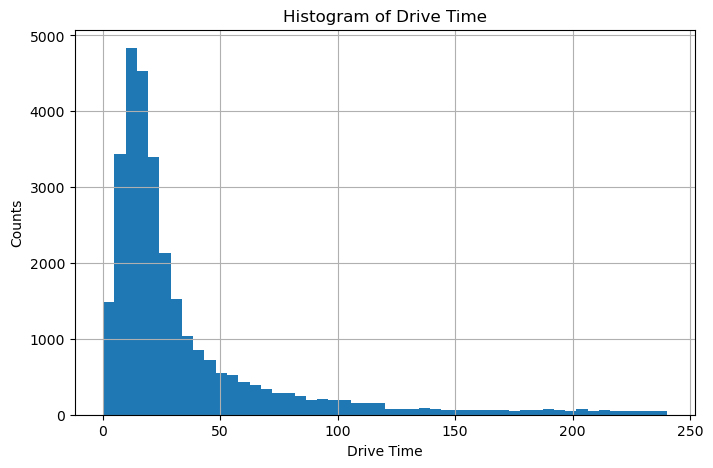

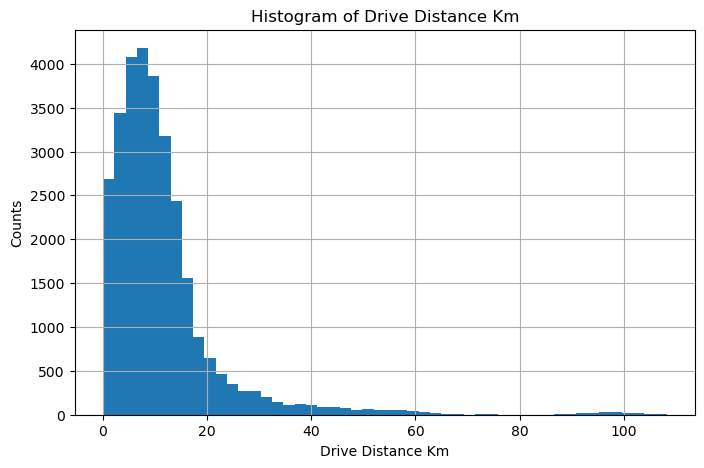

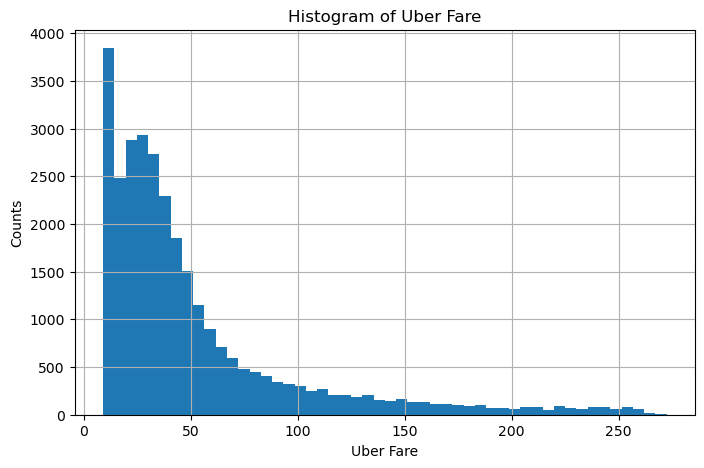

<class 'pandas.core.frame.DataFrame'>
Index: 23717 entries, 0 to 30194
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Pick Up Datetime   23717 non-null  datetime64[ns]
 1   Drop Off Datetime  23717 non-null  datetime64[ns]
 2   Pick Up Lat        23717 non-null  float64       
 3   Pick Up Lon        23717 non-null  float64       
 4   Drop Off Lat       23717 non-null  float64       
 5   Drop Off Lon       23717 non-null  float64       
 6   Drive Time         23717 non-null  float64       
 7   Drive Distance Km  23717 non-null  float64       
 8   Uber Fare          23717 non-null  float64       
 9   Pickup Suburb      23717 non-null  object        
 10  Drop Off Suburb    23717 non-null  object        
dtypes: datetime64[ns](2), float64(7), object(2)
memory usage: 2.2+ MB
         Drive Time  Drive Distance Km     Uber Fare
count  23717.000000       23717.000000  23717.000000
mean

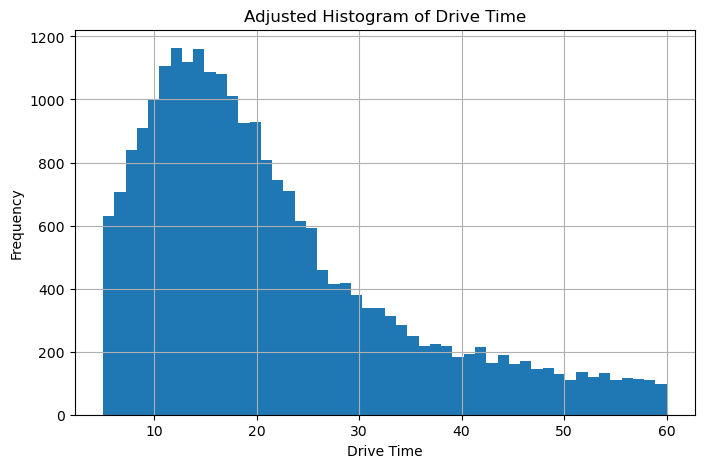

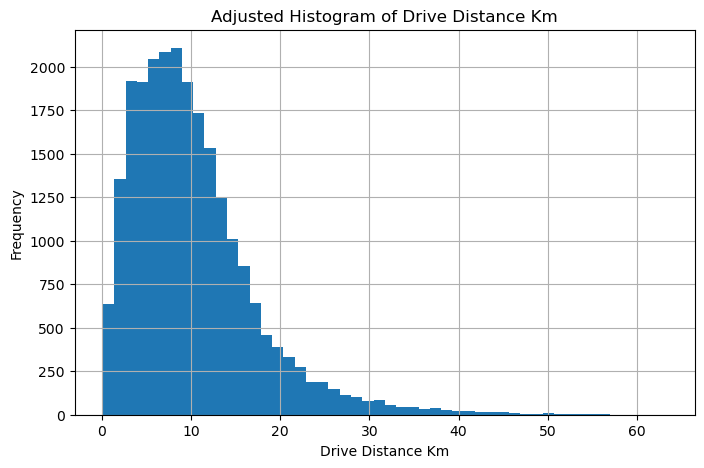

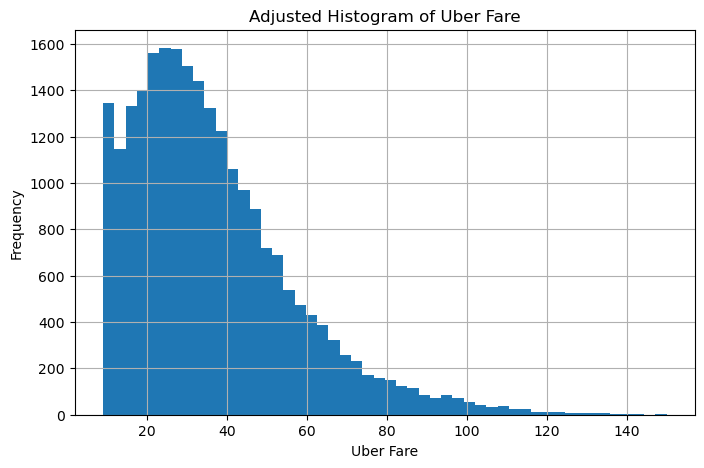

Filtered out 6082 extreme values (drive time of trip <5 or > 60 minutes)


In [2]:
# Data Cleaning
df_org = pd.read_csv("uber_data.csv")
df_org.info()
print(df_org.head())

df_to_clean = df_org.copy()
col_to_remove = ["Trip ID", "Crow Fly Distance", "Pickup State", "Pickup Country", "Pickup Postal Code",
                 "Drop Off Address", "Drop Off Country", "Drop Off Postal Code"]
df = df_to_clean.drop(columns=col_to_remove) # remove the data which we do not include in our analysis.
df.info() # check the new data

col_withNull = df.columns[df.isnull().any()]
print(col_withNull) # to check whether there is any data missing.
df_without_MissingValue = df.dropna() # remove missing value in Pickup Suburb and Drop Off Suburb
df_without_MissingValue.info() # 29827 rows of data left
df = df_without_MissingValue

df["Pick Up Datetime"] = pd.to_datetime(df["Pick Up Datetime"], errors='coerce')
df["Drop Off Datetime"] = pd.to_datetime(df["Drop Off Datetime"], errors='coerce') # make the date to datetime format

df_cleaned = df[(df["Drive Time"] > 0) & (df["Drive Distance Km"] > 0) & (df["Uber Fare"] > 0)]
# make sure we are using valid data, which "Drive Time", "Drive Distance Km", "Uber Fare" should all greater than 0.
df_cleaned.info() # 29799 rows of data after cleaning

print(df_cleaned[["Drive Time", "Drive Distance Km", "Uber Fare"]].describe())
# generate descriptive statistics table for "Drive Time", "Drive Distance Km", "Uber Fare"


columns = ["Drive Time", "Drive Distance Km", "Uber Fare"]

# Create Histograms for "Drive Time", "Drive Distance Km", "Uber Fare" to check the extreme values range.
for col in columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df_cleaned[col], bins=50)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Counts")
    plt.grid(True)
    plt.show() # check the tail to find out the suitable range

df_cleaned_final = df_cleaned[(df_cleaned["Drive Time"] >= 5) & (df_cleaned["Drive Time"] <= 60)]
# Set a drive time range for trips (5 to 60 mins), to remove extreme values.

df_cleaned_final.info() # 23717 rows of data after filter the data.
print(df_cleaned_final[["Drive Time", "Drive Distance Km", "Uber Fare"]].describe())
# generate descriptive statistics table (filtered) for "Drive Time", "Drive Distance Km", "Uber Fare"

# Create and check adjusted histograms with new drive time range filter
for col in columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df_cleaned_final[col], bins=50)
    plt.title(f"Adjusted Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

excluded = len(df_cleaned) - len(df_cleaned_final)
print(f"Filtered out {excluded} extreme values (drive time of trip <5 or > 60 minutes)")

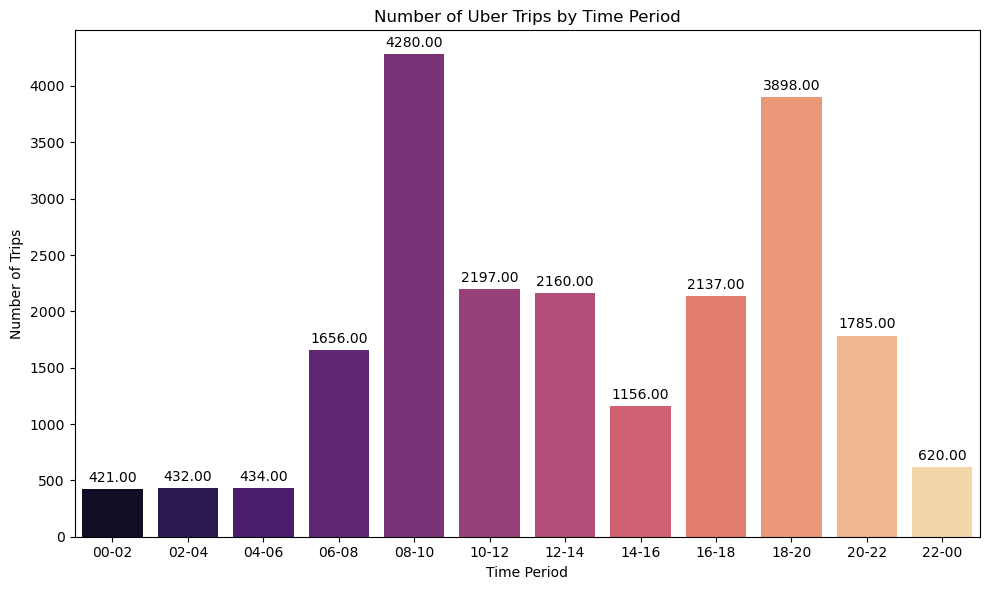

In [3]:
# Define a time classification function
def detailed_time_category(dt):
    hour = dt.hour
    
    if 0 <= hour < 2:
        return '00-02'
    elif 2 <= hour < 4:
        return '02-04'
    elif 4 <= hour < 6:
        return '04-06'
    elif 6 <= hour < 8:
        return '06-08'
    elif 8 <= hour < 10:
        return '08-10'
    elif 10 <= hour < 12:
        return '10-12'
    elif 12 <= hour < 14:
        return '12-14'
    elif 14 < hour < 16:
        return '14-16'
    elif 16 < hour < 18:
        return '16-18'
    elif 18 <= hour < 20:
        return '18-20'
    elif 20 <= hour < 22:
        return '20-22'
    elif 22 <= hour <= 23 :
        return '22-00'

# Apply new classification function
df_cleaned_final = df_cleaned_final.copy()  # will not impact on original data
df_cleaned_final.loc[:, 'Time Period Detailed'] = df_cleaned_final['Pick Up Datetime'].apply(detailed_time_category)

# Order: School Zone appears first
detailed_order = ['00-02', '02-04', '04-06', '06-08', '08-10', '10-12', '12-14', 
              '14-16', '16-18', '18-20', '20-22', '22-00']
detailed_counts = df_cleaned_final['Time Period Detailed'].value_counts().reindex(detailed_order)


#Plot number of Uber Trips by time period
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=detailed_counts.index, y=detailed_counts.values, hue=detailed_counts.index, palette="magma")
# Add numeric labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)
plt.title("Number of Uber Trips by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()


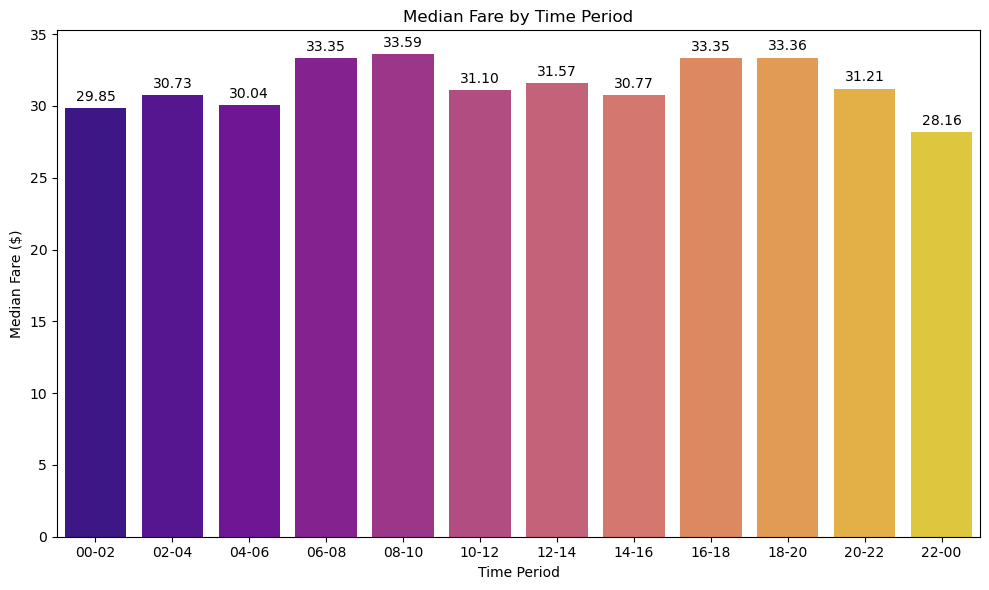

In [4]:
# Median price/km for each time period
median_fare_by_time = df_cleaned_final.groupby('Time Period Detailed')['Uber Fare'].median().reindex(
    ['00-02', '02-04', '04-06', '06-08', '08-10', '10-12', '12-14', 
              '14-16', '16-18', '18-20', '20-22', '22-00'])

# Plot Price/km of each time period
plt.figure(figsize=(10, 6))
ax_2 = sns.barplot(x=median_fare_by_time.index, y=median_fare_by_time.values, hue=median_fare_by_time.index,palette="plasma")
for container in ax_2.containers:
    ax_2.bar_label(container, fmt='%.2f', label_type='edge', padding=3)
plt.title("Median Fare by Time Period")
plt.ylabel("Median Fare ($)")
plt.xlabel("Time Period")
plt.tight_layout()
plt.show()


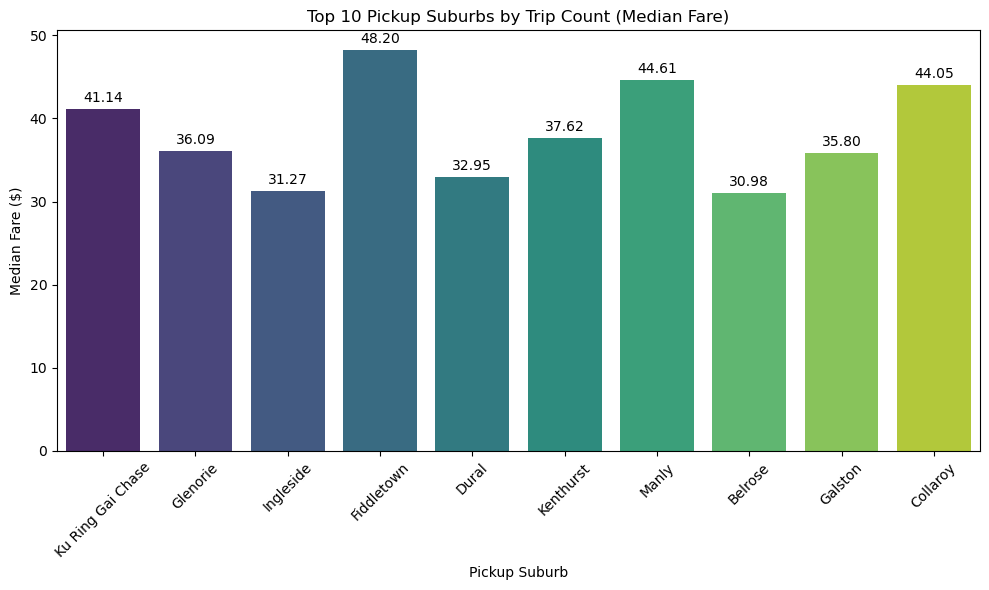

In [5]:
# Number of orders and median price of each Pickup Suburb
suburb_stats = df_cleaned_final.groupby('Pickup Suburb').agg(
    Trip_Count=('Drive Distance Km', 'count'),
    Median_Fare=('Uber Fare', 'median')
).sort_values(by='Trip_Count', ascending=False)

# Graph: The median price of the top 10 most-ordered suburbs
top10 = suburb_stats.head(10).reset_index()

#Plot top 10 pickup suburbs with median fare by Trip Count
plt.figure(figsize=(10, 6))
ax_3 = sns.barplot(data=top10, x='Pickup Suburb', y='Median_Fare', hue='Pickup Suburb', palette='viridis')
for container in ax_3.containers:
    ax_3.bar_label(container, fmt='%.2f', label_type='edge', padding=3)
plt.xticks(rotation=45)
plt.title("Top 10 Pickup Suburbs by Trip Count (Median Fare)")
plt.xlabel("Pickup Suburb")
plt.ylabel("Median Fare ($)")
plt.tight_layout()
plt.show()

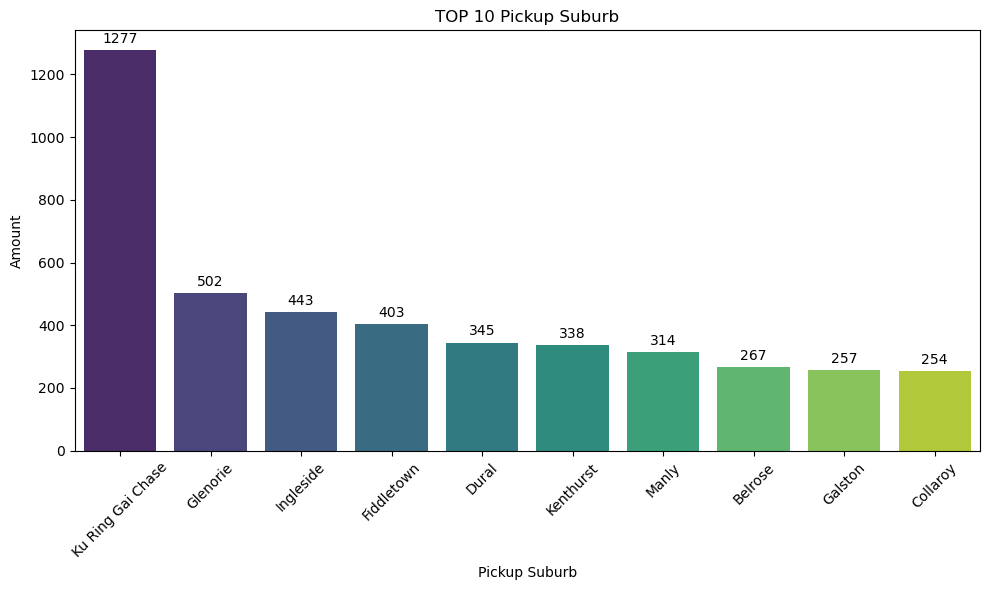

In [6]:
# Find the top 10 pickup suburbs by Trip Count
pickup_counts = df_cleaned_final['Pickup Suburb'].value_counts().head(10)

#Plot top 10 pickup suburbs by Trip Count
plt.figure(figsize=(10, 6))
ax_3 = sns.barplot(x=pickup_counts.index, y=pickup_counts.values, hue=pickup_counts.index, palette='viridis', legend=False)
for container in ax_3.containers:
    ax_3.bar_label(container, fmt='%d', label_type='edge', padding=3)

# setting the chart detail and format
plt.title("TOP 10 Pickup Suburb")
plt.xlabel("Pickup Suburb")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# heatmap for pickup location distribution on Sydney map
df = df_cleaned_final

# 2. Filter suitable areas to improve visualization quality
df = df[
    (df["Pick Up Lat"] >= -34.2) & (df["Pick Up Lat"] <= -33.4) &
    (df["Pick Up Lon"] >= 150.5) & (df["Pick Up Lon"] <= 151.5)
]

# Get heat map point data
heat_data = df[["Pick Up Lat", "Pick Up Lon"]].dropna().values.tolist()

# Creating a Folium map object
m = folium.Map(location=[-33.8688, 151.2093], zoom_start=11)  # ct nearby areas

# Put the heatmap points to the Sdyney map
HeatMap(heat_data, radius=10, blur=15, min_opacity=0.4).add_to(m)

# show the heat map
m

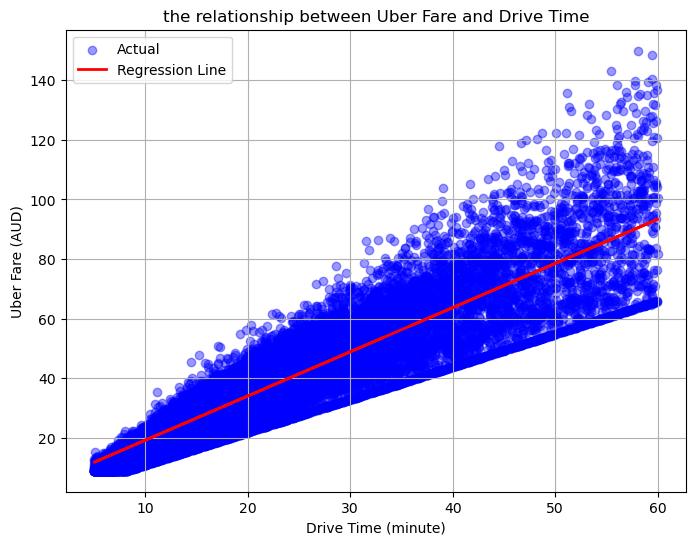

Intercep: 4.4261986884335975
Coefficient: 1.482316438558203
Linear Regression Model : Uber Fare = 1.482 * Drive Time + 4.426
R²: 0.836


In [8]:
# Scatter plot and Linear Regression Model (Drive Time)

# 'Drive Time' as independent variable and 'Uber Fare'as dependent variable
X = df_cleaned_final[['Drive Time']]
Y = df_cleaned_final['Uber Fare']

Time_LR = LinearRegression()
Time_LR.fit(X, Y)
Y_pred = Time_LR.predict(X)

# draw the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', alpha=0.4, label='Actual')
# draw regression line
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line') 

#plot title and labels
plt.title('the relationship between Uber Fare and Drive Time' )
plt.xlabel('Drive Time (minute)')
plt.ylabel('Uber Fare (AUD)')
plt.grid(True)
plt.legend()
plt.show()


# print the intercep ,coefficient and the whole equation.
print("Intercep:", Time_LR.intercept_)
print("Coefficient:", Time_LR.coef_[0])
print(f"Linear Regression Model : Uber Fare = {Time_LR.coef_[0]:.3f} * Drive Time + {Time_LR.intercept_:.3f}")



#check the R square
r2 = r2_score(Y, Y_pred)
print(f"R²: {r2:.3f}")

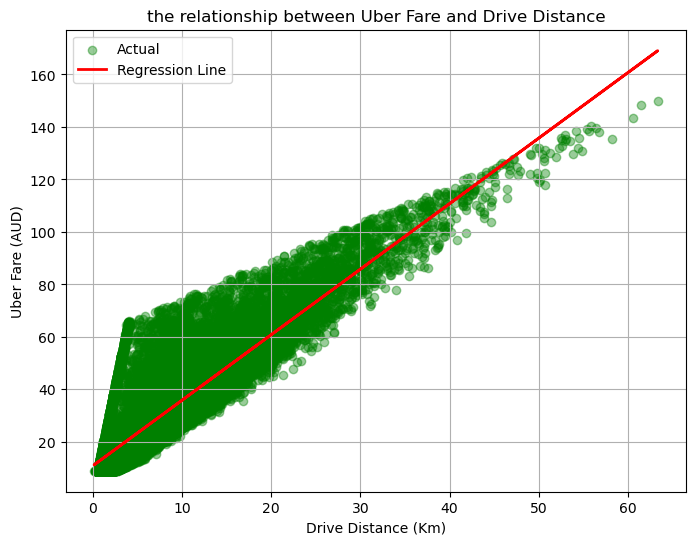

Intercep: 4.4261986884335975
Coefficient: 1.482316438558203
Linear Regression Model : Uber Fare = 2.497 * Drive Distance Km + 10.908
R²: 0.754


In [9]:
# Scatter plot and Linear Regression Model (Drive Distance)

#'Drive Distance' as independent variable and 'Uber Fare'as dependent variable
X = df_cleaned_final[['Drive Distance Km']]
Y = df_cleaned_final['Uber Fare']

Distance_LR = LinearRegression()
Distance_LR.fit(X, Y)

Y_pred = Distance_LR.predict(X)

# draw the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='green', alpha=0.4, label='Actual')
# draw regression line
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')

#plot title and labels
plt.title('the relationship between Uber Fare and Drive Distance')
plt.xlabel('Drive Distance (Km)')
plt.ylabel('Uber Fare (AUD)')
plt.grid(True)
plt.legend()
plt.show()

# print the intercep ,coefficient and the whole equation.
print("Intercep:", Time_LR.intercept_)
print("Coefficient:", Time_LR.coef_[0])
print(f"Linear Regression Model : Uber Fare = {Distance_LR.coef_[0]:.3f} * Drive Distance Km + {Distance_LR.intercept_:.3f}")

#check the R square
r2 = r2_score(Y, Y_pred)
print(f"R²: {r2:.3f}")

In [10]:
# Linear Regression Model (Time and Distance)

#'Drive Time' and 'Drive Distance' as independent variables and 'Uber Fare'as dependent variable
X = df_cleaned_final[['Drive Time','Drive Distance Km']]
Y = df_cleaned_final['Uber Fare']

Time_Distance_LR = LinearRegression()
Time_Distance_LR.fit(X, Y)

Y_pred = Time_Distance_LR.predict(X)

# print the intercep ,coefficient and the whole equation.
print("Intercep:", Time_Distance_LR.intercept_)
print("Coefficient_Time:", Time_Distance_LR.coef_[0])
print("Coefficient_Distance:", Time_Distance_LR.coef_[1])
print(f"Linear Regression Model : Uber Fare = {Time_Distance_LR.coef_[0]:.3f} * Drive Time +  {Time_Distance_LR.coef_[1]:.3f} * Drive Distance KM + {Time_Distance_LR.intercept_:.3f}")

r2 = r2_score(Y, Y_pred)
print(f"R²: {r2:.4f}")


Intercep: 0.0775133792443441
Coefficient_Time: 0.9986847587342118
Coefficient_Distance: 1.4473203746926577
Linear Regression Model : Uber Fare = 0.999 * Drive Time +  1.447 * Drive Distance KM + 0.078
R²: 0.9999
